# 02 - Subgroup analyses and regression

Compares loneliness and mental health across identity groups (sexual orientation, 
race), examines campus belonging and stigma as protective and risk factors, and 
fits multivariate regression models predicting depression and anxiety from 
loneliness controlling for identity, belonging, and stigma.

**Input:** `data/emerging_adults_clean.csv` (produced by `00_clean_data.ipynb`)

**Outputs:**
- `output/loneliness_by_sexual_orientation.png`
- `output/loneliness_by_race.png`
- `output/mental_health_by_belonging.png`
- `output/loneliness_by_perceived_stigma.png`
- `output/regression_depression.csv` — coefficients from the depression model
- `output/regression_anxiety.csv` — coefficients from the anxiety model
- `regression_loneliness.csv`
- `regression_stigma_interaction.csv`
- `regression_interaction.csv`
- Printed text in the notebook: group means by subgroup, effect sizes (Cohen's d), 
  and regression R-squared and coefficient interpretations

## Setup and data loading

Imports and loads `emerging_adults_clean.csv`.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

emerging_adults = pd.read_csv("../data/emerging_adults_clean.csv")

## Loneliness by sexual orientation

My research question asks how loneliness relates to mental health, but the 
relationship may not affect all students equally. Sexual minority students face 
identity-specific stressors — discrimination, stigma, concealment — that elevate 
both loneliness and depression risk. Following Meyer's (2003) minority stress 
theory, I expect higher loneliness among sexual minority students.

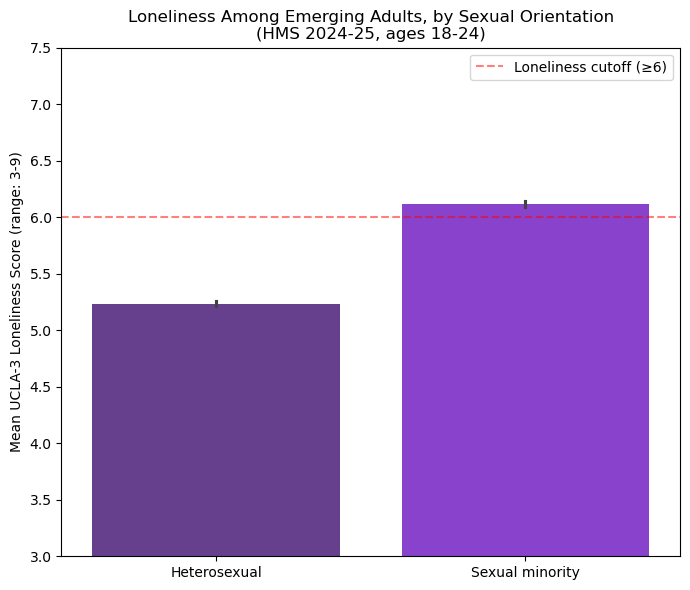

Heterosexual:    M = 5.24, SD = 1.90, n = 32431
Sexual minority: M = 6.12, SD = 1.87, n = 17507
Welch's t = -50.177, p = 0.0000
Cohen's d = 0.468


In [28]:
# plot loneliness by binary sexual minority status
plt.figure(figsize=(7, 6))
sns.barplot(data=emerging_adults, x="sexual_orientation_binary", y="lonesc",
            order=["Heterosexual", "Sexual minority"],
            hue="sexual_orientation_binary",
            palette={"Heterosexual": "rebeccapurple", "Sexual minority": "blueviolet"},
            errorbar="ci", legend=False)
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness Among Emerging Adults, by Sexual Orientation\n(HMS 2024-25, ages 18-24)")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (range: 3-9)")
plt.ylim(3, 7.5)
plt.legend()
plt.tight_layout()
plt.savefig("../output/loneliness_by_sexual_minority_status.png", dpi=150, bbox_inches="tight")
plt.show()

# effect size and significance test
het  = emerging_adults.loc[emerging_adults["sexual_orientation_binary"] == "Heterosexual", "lonesc"].dropna()
smin = emerging_adults.loc[emerging_adults["sexual_orientation_binary"] == "Sexual minority",  "lonesc"].dropna()

# Cohen's d (pooled SD)
pooled_sd = np.sqrt((het.var(ddof=1) * (len(het) - 1) + smin.var(ddof=1) * (len(smin) - 1))
                    / (len(het) + len(smin) - 2))
cohens_d = (smin.mean() - het.mean()) / pooled_sd

t_stat, p_val = stats.ttest_ind(het, smin, equal_var=False)  # Welch's t-test
print(f"Heterosexual:    M = {het.mean():.2f}, SD = {het.std():.2f}, n = {len(het)}")
print(f"Sexual minority: M = {smin.mean():.2f}, SD = {smin.std():.2f}, n = {len(smin)}")
print(f"Welch's t = {t_stat:.3f}, p = {p_val:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")

### Loneliness across detailed sexual orientation categories

The binary contrast shows sexual minorities collectively have higher loneliness, 
but doesn't reveal *which* groups are most affected. Disaggregating into nine 
categories reveals the pattern within.

In [3]:
loneliness_by_orient = (emerging_adults.groupby("sexual_orientation")["lonesc"]
                        .agg(["mean", "median", "count"])
                        .round(2)
                        .sort_values("mean"))
print(loneliness_by_orient)

                    mean  median  count
sexual_orientation                     
Heterosexual        5.23     5.0  32373
Self-described      5.52     6.0    588
Gay                 5.96     6.0   1125
Lesbian             5.99     6.0   2055
Asexual             6.02     6.0   1179
Bisexual            6.08     6.0   8438
Questioning         6.24     6.0   1116
Queer               6.30     6.0   1984
Pansexual           6.40     6.0   1610


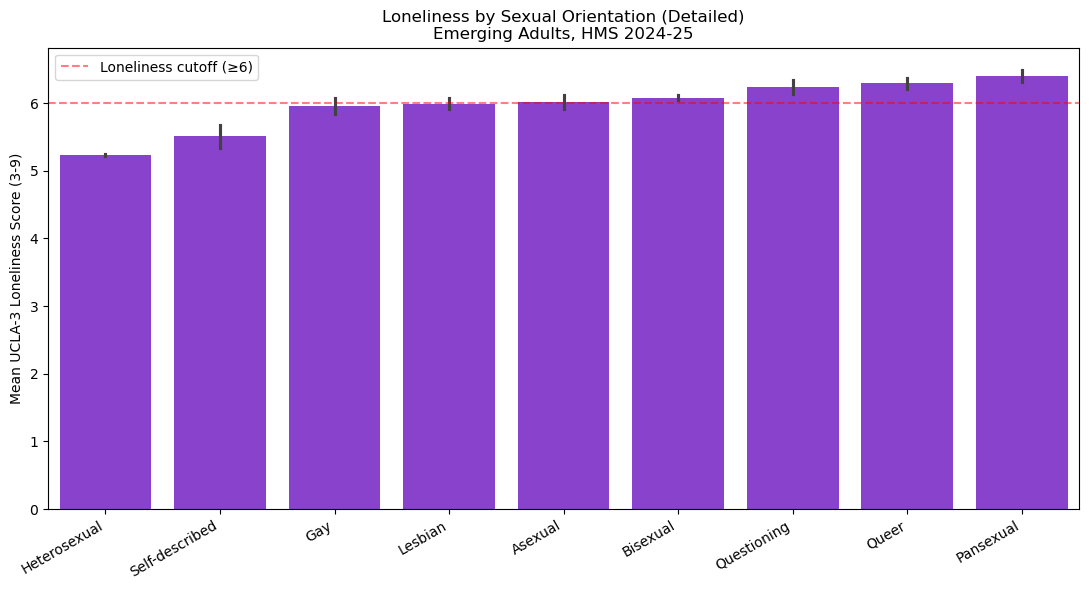

In [35]:
orientation_order = loneliness_by_orient.index.tolist()

plt.figure(figsize=(11, 6))
sns.barplot(data=emerging_adults, x="sexual_orientation", y="lonesc",
            order=orientation_order, color="blueviolet", errorbar="ci")
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness by Sexual Orientation (Detailed)\nEmerging Adults, HMS 2024-25")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (3-9)")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("../output/loneliness_by_sexual_orientation_detailed.png", dpi=150, bbox_inches="tight")
plt.show()

## Loneliness by race

If loneliness is unequally distributed by race, the burden of any loneliness–
mental-health link will fall unevenly across racial groups. Following research 
on racial minority students' campus experiences, I expect elevated loneliness 
among racial minority students relative to white peers.

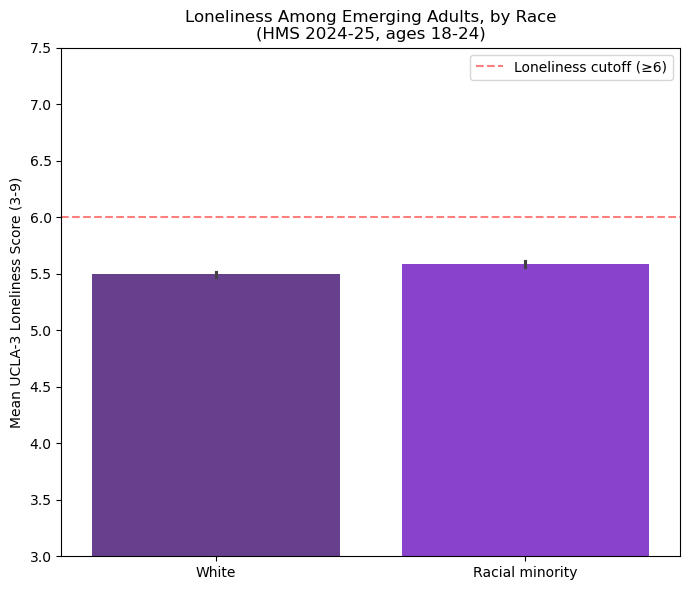

White:           M = 5.49, SD = 1.94, n = 26976
Racial minority: M = 5.59, SD = 1.94, n = 25610
Welch's t = -5.725, p = 0.0000
Cohen's d = 0.050


In [29]:
plt.figure(figsize=(7, 6))
sns.barplot(data=emerging_adults, x="race_status", y="lonesc",
            order=["White", "Racial minority"],
            hue="race_status",
            palette={"White": "rebeccapurple", "Racial minority": "blueviolet"},
            errorbar="ci", legend=False)
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness Among Emerging Adults, by Race\n(HMS 2024-25, ages 18-24)")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (3-9)")
plt.ylim(3, 7.5)
plt.legend()
plt.tight_layout()
plt.savefig("../output/loneliness_by_race.png", dpi=150, bbox_inches="tight")
plt.show()

# effect size and significance test
white = emerging_adults.loc[emerging_adults["race_status"] == "White",          "lonesc"].dropna()
rmin  = emerging_adults.loc[emerging_adults["race_status"] == "Racial minority", "lonesc"].dropna()

pooled_sd = np.sqrt((white.var(ddof=1) * (len(white) - 1) + rmin.var(ddof=1) * (len(rmin) - 1))
                    / (len(white) + len(rmin) - 2))
cohens_d_race = (rmin.mean() - white.mean()) / pooled_sd

t_stat_r, p_val_r = stats.ttest_ind(white, rmin, equal_var=False)
print(f"White:           M = {white.mean():.2f}, SD = {white.std():.2f}, n = {len(white)}")
print(f"Racial minority: M = {rmin.mean():.2f}, SD = {rmin.std():.2f}, n = {len(rmin)}")
print(f"Welch's t = {t_stat_r:.3f}, p = {p_val_r:.4f}")
print(f"Cohen's d = {cohens_d_race:.3f}")

## Belonging as a protective factor

My research question asks not just where loneliness is highest, but also what 
might buffer against it. Campus belonging is a candidate protective factor — 
students who feel connected to their campus may report less loneliness. Bin 
students into belonging tertiles (low, moderate, high) and compare mean 
loneliness across them.

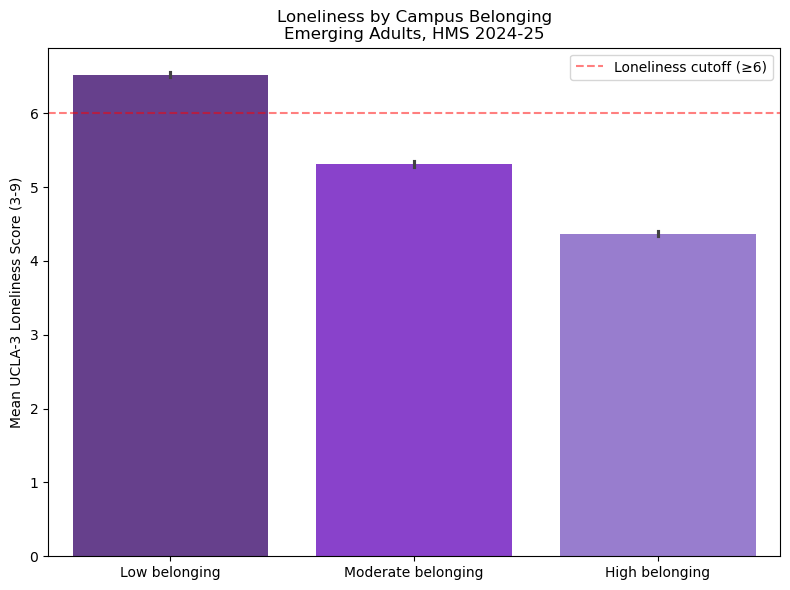

In [31]:
emerging_adults["belong_tertile"] = pd.qcut(
    emerging_adults["belong_total"],
    q=3,
    labels=["Low belonging", "Moderate belonging", "High belonging"])

plt.figure(figsize=(8, 6))
sns.barplot(data=emerging_adults, x="belong_tertile", y="lonesc",
            order=["Low belonging", "Moderate belonging", "High belonging"],
            hue="belong_tertile",
            palette={"Low belonging": "rebeccapurple", 
                     "Moderate belonging": "blueviolet", 
                     "High belonging": "mediumpurple"},
            errorbar="ci", legend=False)
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness by Campus Belonging\nEmerging Adults, HMS 2024-25")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (3-9)")
plt.legend()
plt.tight_layout()
plt.savefig("../output/loneliness_by_belonging.png", dpi=150, bbox_inches="tight")
plt.show()

## Stigma as a risk factor

If belonging is a candidate buffer, perceived stigma is a candidate risk factor. 
Students who think their environment judges mental health negatively may 
experience more isolation, regardless of actual stigma. Compare loneliness 
across perceived stigma tertiles.

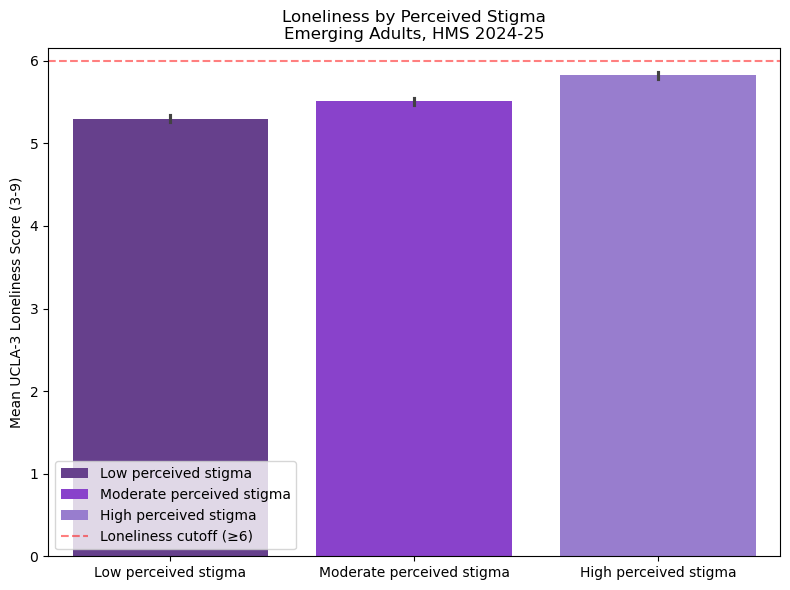

In [33]:
emerging_adults["perceived_stigma_tertile"] = pd.qcut(
    emerging_adults["stigma_perceived"],
    q=3,
    labels=["Low perceived stigma", "Moderate perceived stigma", "High perceived stigma"]
)

plt.figure(figsize=(8, 6))
sns.barplot(data=emerging_adults, x="perceived_stigma_tertile", y="lonesc",
            order=["Low perceived stigma", "Moderate perceived stigma", "High perceived stigma"],
            hue="perceived_stigma_tertile",
            palette={"Low perceived stigma": "rebeccapurple", 
                     "Moderate perceived stigma": "blueviolet", 
                     "High perceived stigma": "mediumpurple"},
            errorbar="ci")
plt.axhline(6, color="red", linestyle="--", alpha=0.5, label="Loneliness cutoff (≥6)")
plt.title("Loneliness by Perceived Stigma\nEmerging Adults, HMS 2024-25")
plt.xlabel("")
plt.ylabel("Mean UCLA-3 Loneliness Score (3-9)")
plt.legend()
plt.tight_layout()
plt.savefig("../output/loneliness_by_perceived_stigma.png", dpi=150, bbox_inches="tight")
plt.show()

## Multivariate regression — setup

Selects variables for the regression models, drops rows with missing values, and dummy-encodes categorical predictors (gender, sexual orientation, race). Reference categories are set to Woman, Heterosexual, and White so coefficients read as comparisons to these natural baselines.

In [8]:
# Variables for the regression
model_vars = ["phq9_total", "gad7_total", "lonesc", "belong_total",
              "stigma_self", "stigma_perceived", "age",
              "gender", "sexual_orientation", "race_status"]
model_df = emerging_adults[model_vars].dropna().copy()

print(f"Full emerging adult sample:      {len(emerging_adults):,}")
print(f"Complete-case regression sample: {len(model_df):,}")
print(f"Dropped due to missing values:   {len(emerging_adults) - len(model_df):,}")

Full emerging adult sample:      61,288
Complete-case regression sample: 17,120
Dropped due to missing values:   44,168


In [9]:
# Set explicit reference categories so coefficients are interpretable
gender_order = ["Woman", "Man", "Nonbinary", "Genderqueer", "Trans", "Self-described"]
model_df["gender"] = pd.Categorical(model_df["gender"], categories=gender_order, ordered=False)

orientation_order = ["Heterosexual", "Lesbian", "Gay", "Bisexual", "Pansexual",
                     "Queer", "Questioning", "Asexual", "Self-described"]
model_df["sexual_orientation"] = pd.Categorical(
    model_df["sexual_orientation"], categories=orientation_order, ordered=False)

race_order = ["White", "Racial minority"]
model_df["race_status"] = pd.Categorical(model_df["race_status"], categories=race_order, ordered=False)

# Encode dummies, dropping the reference (first) category
model_encoded = pd.get_dummies(
    model_df,
    columns=["gender", "sexual_orientation", "race_status"],
    drop_first=True
)
# Force booleans to 0/1
model_encoded = model_encoded.astype(
    {col: int for col in model_encoded.columns if model_encoded[col].dtype == bool})

## Multivariate regression - depression

Predicts PHQ-9 depression from loneliness, belonging, stigma, age, and dummy-encoded demographic controls entered simultaneously using statsmodels OLS. Reports coefficients and p-values for each predictor.

In [10]:
y_dep = model_encoded["phq9_total"]
X = model_encoded.drop(columns=["phq9_total", "gad7_total"])
X_const = sm.add_constant(X)

ols_dep = sm.OLS(y_dep, X_const).fit()

coefs_dep = pd.DataFrame({
    "predictor":   ols_dep.params.index,
    "coefficient": ols_dep.params.round(3),
    "p_value":     ols_dep.pvalues.round(4),
}).sort_values("coefficient", key=abs, ascending=False)

print(f"=== DEPRESSION (PHQ-9) MODEL ===")
print(f"Reference groups: Woman, Heterosexual, White")
print(f"R-squared: {ols_dep.rsquared:.3f}")
print(f"Intercept: {ols_dep.params['const']:.3f}\n")
print(coefs_dep.to_string(index=False))

coefs_dep.to_csv("../output/regression_depression.csv", index=False)

=== DEPRESSION (PHQ-9) MODEL ===
Reference groups: Woman, Heterosexual, White
R-squared: 0.360
Intercept: 2.459

                        predictor  coefficient  p_value
     sexual_orientation_Pansexual        2.512   0.0000
                            const        2.459   0.0000
         sexual_orientation_Queer        1.968   0.0000
      sexual_orientation_Bisexual        1.639   0.0000
       sexual_orientation_Lesbian        1.605   0.0000
                     gender_Trans        1.265   0.0000
                           lonesc        1.259   0.0000
            gender_Self-described        1.241   0.1217
           sexual_orientation_Gay        1.233   0.0000
   sexual_orientation_Questioning        1.178   0.0000
sexual_orientation_Self-described        1.021   0.0075
                 gender_Nonbinary        0.988   0.0000
                       gender_Man       -0.970   0.0000
       sexual_orientation_Asexual        0.928   0.0005
               gender_Genderqueer        0.654 

## Multivariate regression - anxiety

The same statsmodels OLS model now predicting GAD-7 anxiety. Comparing p-values and coefficients across both models shows which findings generalize across outcomes.

In [11]:
y_anx = model_encoded["gad7_total"]

ols_anx = sm.OLS(y_anx, X_const).fit()

coefs_anx = pd.DataFrame({
    "predictor":   ols_anx.params.index,
    "coefficient": ols_anx.params.round(3),
    "p_value":     ols_anx.pvalues.round(4),
}).sort_values("coefficient", key=abs, ascending=False)

print(f"=== ANXIETY (GAD-7) MODEL ===")
print(f"Reference groups: Woman, Heterosexual, White")
print(f"R-squared: {ols_anx.rsquared:.3f}")
print(f"Intercept: {ols_anx.params['const']:.3f}\n")
print(coefs_anx.to_string(index=False))

coefs_anx.to_csv("../output/regression_anxiety.csv", index=False)

=== ANXIETY (GAD-7) MODEL ===
Reference groups: Woman, Heterosexual, White
R-squared: 0.285
Intercept: 1.134

                        predictor  coefficient  p_value
                       gender_Man       -2.149   0.0000
     sexual_orientation_Pansexual        1.970   0.0000
         sexual_orientation_Queer        1.616   0.0000
           sexual_orientation_Gay        1.532   0.0000
       sexual_orientation_Lesbian        1.346   0.0000
      sexual_orientation_Bisexual        1.343   0.0000
                            const        1.134   0.0406
                           lonesc        1.088   0.0000
   sexual_orientation_Questioning        1.081   0.0000
            gender_Self-described       -0.839   0.2888
                     gender_Trans       -0.481   0.0996
      race_status_Racial minority       -0.273   0.0003
               gender_Genderqueer       -0.201   0.4365
       sexual_orientation_Asexual        0.167   0.5265
                     belong_total       -0.163   0

## Loneliness regression - who is most susceptible?

Predicts UCLA-3 loneliness from identity, belonging, stigma, and age using statsmodels OLS. This tests whether identity groups differ in loneliness after controlling for other factors.

In [12]:
y_lone = model_encoded["lonesc"]
X_lone = model_encoded.drop(columns=["phq9_total", "gad7_total", "lonesc"])
X_lone_const = sm.add_constant(X_lone)

ols_lone = sm.OLS(y_lone, X_lone_const).fit()

coefs_lone = pd.DataFrame({
    "predictor":   ols_lone.params.index,
    "coefficient": ols_lone.params.round(3),
    "p_value":     ols_lone.pvalues.round(4),
}).sort_values("coefficient", key=abs, ascending=False)
coefs_lone = coefs_lone[coefs_lone["predictor"] != "const"]

print(f"=== LONELINESS (UCLA-3) MODEL ===")
print(f"Reference groups: Woman, Heterosexual, White")
print(f"R-squared: {ols_lone.rsquared:.3f}")
print(f"Intercept: {ols_lone.params['const']:.3f}\n")
print(coefs_lone.to_string(index=False))

coefs_lone.to_csv("../output/regression_loneliness.csv", index=False)

=== LONELINESS (UCLA-3) MODEL ===
Reference groups: Woman, Heterosexual, White
R-squared: 0.309
Intercept: 9.544

                        predictor  coefficient  p_value
     sexual_orientation_Pansexual        0.669   0.0000
   sexual_orientation_Questioning        0.643   0.0000
           sexual_orientation_Gay        0.581   0.0000
         sexual_orientation_Queer        0.580   0.0000
      sexual_orientation_Bisexual        0.503   0.0000
       sexual_orientation_Lesbian        0.417   0.0000
               gender_Genderqueer        0.406   0.0000
                     gender_Trans        0.349   0.0003
       sexual_orientation_Asexual        0.345   0.0001
                 gender_Nonbinary        0.322   0.0000
                     belong_total       -0.234   0.0000
            gender_Self-described        0.210   0.4241
                       gender_Man       -0.198   0.0000
                              age       -0.050   0.0000
                      stigma_self        0.045

## Stigma as a risk factor - interaction model

Tests whether perceived stigma amplifies the relationship between loneliness and depression. A significant positive interaction term (lonesc × stigma_perceived) would confirm that stigma makes students more vulnerable to the effects of loneliness.

In [13]:
# Drop any previous interaction terms to keep the model clean
model_encoded = model_encoded.drop(columns=[col for col in model_encoded.columns 
                                             if col.startswith("lonesc_x")], errors="ignore")

# Create the interaction term
model_encoded["lonesc_x_stigma"] = model_encoded["lonesc"] * model_encoded["stigma_perceived"]

y_dep = model_encoded["phq9_total"]
X_stig = model_encoded.drop(columns=["phq9_total", "gad7_total"])
X_stig_const = sm.add_constant(X_stig)

ols_stig = sm.OLS(y_dep, X_stig_const).fit()

key_terms = ["lonesc", "stigma_perceived", "lonesc_x_stigma"]
coefs_stig = pd.DataFrame({
    "predictor":   ols_stig.params.index,
    "coefficient": ols_stig.params.round(3),
    "p_value":     ols_stig.pvalues.round(4),
}).sort_values("coefficient", key=abs, ascending=False)
coefs_stig = coefs_stig[coefs_stig["predictor"] != "const"]

print(f"=== INTERACTION MODEL: STIGMA AS RISK FACTOR ===")
print(f"R-squared: {ols_stig.rsquared:.3f}\n")
print("Key terms:")
print(coefs_stig[coefs_stig["predictor"].isin(key_terms)].to_string(index=False))
print("\nFull model:")
print(coefs_stig.to_string(index=False))

coefs_stig.to_csv("../output/regression_stigma_interaction.csv", index=False)

=== INTERACTION MODEL: STIGMA AS RISK FACTOR ===
R-squared: 0.361

Key terms:
       predictor  coefficient  p_value
          lonesc        1.028   0.0000
stigma_perceived       -0.083   0.0377
 lonesc_x_stigma        0.029   0.0000

Full model:
                        predictor  coefficient  p_value
     sexual_orientation_Pansexual        2.513   0.0000
         sexual_orientation_Queer        1.980   0.0000
      sexual_orientation_Bisexual        1.642   0.0000
       sexual_orientation_Lesbian        1.608   0.0000
                     gender_Trans        1.265   0.0000
            gender_Self-described        1.259   0.1162
           sexual_orientation_Gay        1.234   0.0000
   sexual_orientation_Questioning        1.169   0.0000
                           lonesc        1.028   0.0000
sexual_orientation_Self-described        1.018   0.0077
                 gender_Nonbinary        0.995   0.0000
                       gender_Man       -0.965   0.0000
       sexual_orientation

## Belonging as a buffer - interaction model

Tests whether belonging weakens the relationship between loneliness and depression. A significant negative interaction term (lonesc × belong_total) would confirm that belonging buffers the effect of loneliness on depression.

In [14]:
# Drop any previous interaction terms to keep the model clean
model_encoded = model_encoded.drop(columns=[col for col in model_encoded.columns 
                                             if col.startswith("lonesc_x")], errors="ignore")

# Create the interaction term
model_encoded["lonesc_x_belonging"] = model_encoded["lonesc"] * model_encoded["belong_total"]

y_dep = model_encoded["phq9_total"]
X_int = model_encoded.drop(columns=["phq9_total", "gad7_total"])
X_int_const = sm.add_constant(X_int)

ols_int = sm.OLS(y_dep, X_int_const).fit()

# Pull out just the key terms for clarity
key_terms = ["lonesc", "belong_total", "lonesc_x_belonging"]
coefs_int = pd.DataFrame({
    "predictor":   ols_int.params.index,
    "coefficient": ols_int.params.round(3),
    "p_value":     ols_int.pvalues.round(4),
}).sort_values("coefficient", key=abs, ascending=False)
coefs_int = coefs_int[coefs_int["predictor"] != "const"]

print(f"=== INTERACTION MODEL: BELONGING AS BUFFER ===")
print(f"R-squared: {ols_int.rsquared:.3f}\n")
print("Key terms:")
print(coefs_int[coefs_int["predictor"].isin(key_terms)].to_string(index=False))
print("\nFull model:")
print(coefs_int.to_string(index=False))

coefs_int.to_csv("../output/regression_interaction.csv", index=False)

=== INTERACTION MODEL: BELONGING AS BUFFER ===
R-squared: 0.361

Key terms:
         predictor  coefficient  p_value
            lonesc        1.395   0.0000
      belong_total       -0.210   0.0000
lonesc_x_belonging       -0.009   0.0531

Full model:
                        predictor  coefficient  p_value
     sexual_orientation_Pansexual        2.524   0.0000
         sexual_orientation_Queer        1.979   0.0000
      sexual_orientation_Bisexual        1.645   0.0000
       sexual_orientation_Lesbian        1.615   0.0000
                           lonesc        1.395   0.0000
                     gender_Trans        1.255   0.0000
           sexual_orientation_Gay        1.240   0.0000
            gender_Self-described        1.230   0.1251
   sexual_orientation_Questioning        1.180   0.0000
sexual_orientation_Self-described        1.020   0.0076
                 gender_Nonbinary        0.982   0.0000
                       gender_Man       -0.971   0.0000
       sexual_orien